In [14]:
import pandas as pd

# ========== CONFIGURATION ==========
CSV_PATH    = r"C:\Users\pljh0187\Desktop\Senushi\Book1.csv"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
# ====================================

df = pd.read_csv(CSV_PATH)
df["Name"]   = df["Name"].str.strip()
df["SMILES"] = df["SMILES"].str.strip()

original_count = len(df)

# Keep first occurrence, drop exact duplicates (Name + SMILES both same)
df_cleaned = df.drop_duplicates(subset=["Name", "SMILES"], keep="first")

removed_count = original_count - len(df_cleaned)

df_cleaned.to_csv(OUTPUT_PATH, index=False)

print(f"Original rows : {original_count}")
print(f"Rows removed  : {removed_count}")
print(f"Remaining rows: {len(df_cleaned)}")
print(f"Saved to      : {OUTPUT_PATH}")

Original rows : 504
Rows removed  : 113
Remaining rows: 391
Saved to      : C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv


Double checking Book1_cleaned for duplicates

In [15]:
import pandas as pd

# ========== CONFIGURATION ==========
CSV_PATH    = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\conflicts.xlsx"
# ====================================

df = pd.read_csv(CSV_PATH)
df["Name"]   = df["Name"].str.strip()
df["SMILES"] = df["SMILES"].str.strip()

# --- Same Name, Different SMILES ---
# Names that appear more than once but with different SMILES strings
dup_name = df[df.duplicated(subset=["Name"], keep=False)].copy()
dup_name = dup_name.sort_values("Name")

# --- Same SMILES, Different Name ---
# SMILES that appear more than once but with different compound names
dup_smiles = df[df.duplicated(subset=["SMILES"], keep=False)].copy()
dup_smiles = dup_smiles.sort_values("SMILES")

# --- Summary ---
summary = pd.DataFrame({
    "Issue": [
        "Same Name, Different SMILES",
        "Same SMILES, Different Name"
    ],
    "Number of affected rows": [
        len(dup_name),
        len(dup_smiles)
    ]
})

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    summary.to_excel(writer,    sheet_name="Summary",                    index=False)
    dup_name.to_excel(writer,   sheet_name="Same Name Diff SMILES",      index=False)
    dup_smiles.to_excel(writer, sheet_name="Same SMILES Diff Name",      index=False)

print(f"Done! Saved to: {OUTPUT_PATH}")
print(f"  Same Name, Different SMILES : {len(dup_name)} rows")
print(f"  Same SMILES, Different Name : {len(dup_smiles)} rows")

Done! Saved to: C:\Users\pljh0187\Desktop\Senushi\conflicts.xlsx
  Same Name, Different SMILES : 22 rows
  Same SMILES, Different Name : 7 rows


Plot for Book1_cleaned

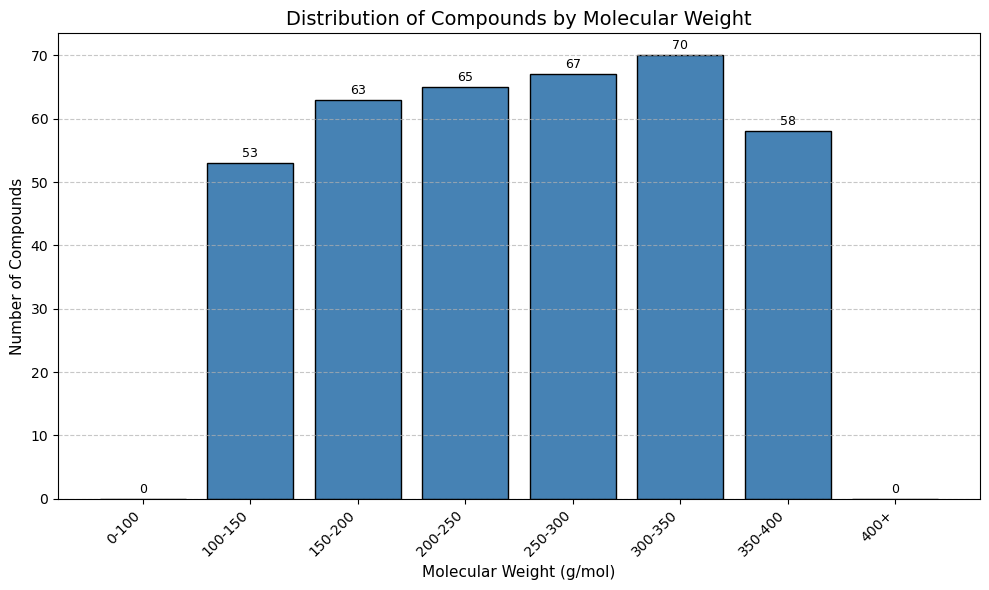

MW_bin
0-100       0
100-150    53
150-200    63
200-250    65
250-300    67
300-350    70
350-400    58
400+        0
Name: count, dtype: int64


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
file_path = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
df = pd.read_csv(file_path)

# Drop any rows with missing MW (just in case)
df = df.dropna(subset=['MW'])

# Define MW bins (adjust as you like)
bins = [0, 100, 150, 200, 250, 300, 350, 400, 1000]
labels = ['0-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400+']

# Bin the MW values
df['MW_bin'] = pd.cut(df['MW'], bins=bins, labels=labels, right=False)

# Count compounds per bin
bin_counts = df['MW_bin'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(bin_counts.index, bin_counts.values, color='steelblue', edgecolor='black')

# Add labels, title, and grid
plt.xlabel('Molecular Weight (g/mol)', fontsize=11)
plt.ylabel('Number of Compounds', fontsize=11)
plt.title('Distribution of Compounds by Molecular Weight', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Optional: print the counts
print(bin_counts)

Calculating MW for basf_data file.

In [26]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

# ------------------------------------------------------------------
# 1. Load the Excel file
file_path = r"C:\Users\pljh0187\Desktop\Senushi\basf_data.xlsx"
df = pd.read_excel(file_path, sheet_name="in")   # sheet name is "in"
# ------------------------------------------------------------------

# ------------------------------------------------------------------
# 2. Keep only the first occurrence of each unique (solute_name, solute_smiles)
#    This removes duplicates caused by different solvents.
unique_df = df.drop_duplicates(subset=['solute_name', 'solute_smiles'])

# Alternatively, you could drop duplicates only by SMILES (keeping first name):
# unique_df = df.drop_duplicates(subset=['solute_smiles'])

# ------------------------------------------------------------------
# 3. Define function to compute MW from SMILES
def calculate_mw(smiles):
    if not isinstance(smiles, str):
        return np.nan
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Descriptors.MolWt(mol)

# ------------------------------------------------------------------
# 4. Apply MW calculation
unique_df['MW'] = unique_df['solute_smiles'].apply(calculate_mw)

# ------------------------------------------------------------------
# 5. Select only the required columns
output_df = unique_df[['solute_name', 'solute_smiles', 'MW']].copy()
output_df.columns = ['Name', 'SMILES', 'MW']   # rename columns as requested

# ------------------------------------------------------------------
# 6. Save to new Excel file
output_path = r"C:\Users\pljh0187\Desktop\Senushi\basf_cleaned.xlsx"
output_df.to_excel(output_path, index=False)
print(f"Saved {len(output_df)} unique compounds to {output_path}")

# Optional: print rows where MW could not be calculated
invalid = output_df[output_df['MW'].isna()]
if not invalid.empty:
    print("\nInvalid SMILES (MW = NaN):")
    print(invalid[['Name', 'SMILES']])

[17:42:13] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13 14 15 16 17
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 12 13 14 15 16 17
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24 25 26 27 28
[17:42:13] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15
[17:42:14] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 18
[17:42:14] Can't k

Saved 3944 unique compounds to C:\Users\pljh0187\Desktop\Senushi\basf_cleaned.xlsx

Invalid SMILES (MW = NaN):
                                            Name  \
98    (E)-1-(4-Chlorophenyl)-N-phenylmethanimine   
550                               1,2,4-triazole   
561                      1,2,4-triazole DONOTUSE   
1249                   2-methyl-4-nitroimidazole   
1257                       2-methylbenzimidazole   
1900                        3-indoleacrylic acid   
3195                            6-mercaptopurine   
4014                                azathioprine   
4418             benzotriazole-5-carboxylic acid   
4430                             benzylimidazole   
4593                                bromogramine   
4802                                   carprofen   
4804                                  carvedilol   
4955                                  cimetidine   
6241                         glycyl-L-tryptophan   
6589                        indole-3-acetic acid   
6744 

[17:42:14] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13 14 15 16 17
[17:42:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 6 8
[17:42:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[17:42:14] Can't kekulize mol.  Unkekulized atoms: 22 23 24 25 26


Double check if the data is cleaned or not in basf_cleaned file.

In [27]:
import pandas as pd

# ========== CONFIGURATION ==========
FILE_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_cleaned.xlsx"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_duplicates.xlsx"
# ====================================

# Read the cleaned file
df = pd.read_excel(FILE_PATH)

# Remove any leading/trailing spaces
df["Name"]   = df["Name"].astype(str).str.strip()
df["SMILES"] = df["SMILES"].astype(str).str.strip()

# --- Duplicates by Name ---
dup_name = df[df.duplicated(subset=["Name"], keep=False)].copy()
dup_name = dup_name.sort_values("Name")

# --- Duplicates by SMILES ---
dup_smiles = df[df.duplicated(subset=["SMILES"], keep=False)].copy()
dup_smiles = dup_smiles.sort_values("SMILES")

# --- Duplicates by both Name AND SMILES ---
dup_both = df[df.duplicated(subset=["Name", "SMILES"], keep=False)].copy()
dup_both = dup_both.sort_values(["Name", "SMILES"])

# --- Summary counts ---
summary = pd.DataFrame({
    "Check": [
        "Duplicate Name",
        "Duplicate SMILES",
        "Duplicate Name AND SMILES"
    ],
    "Number of affected rows": [
        len(dup_name),
        len(dup_smiles),
        len(dup_both)
    ]
})

# --- Write to Excel ---
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="Summary", index=False)
    dup_name.to_excel(writer, sheet_name="Duplicate Names", index=False)
    dup_smiles.to_excel(writer, sheet_name="Duplicate SMILES", index=False)
    dup_both.to_excel(writer, sheet_name="Duplicate Name+SMILES", index=False)

print(f"Done! Duplicates saved to: {OUTPUT_PATH}")
print(f"  Duplicate names          : {len(dup_name)} rows")
print(f"  Duplicate SMILES         : {len(dup_smiles)} rows")
print(f"  Duplicate name + SMILES  : {len(dup_both)} rows")

Done! Duplicates saved to: C:\Users\pljh0187\Desktop\Senushi\basf_duplicates.xlsx
  Duplicate names          : 983 rows
  Duplicate SMILES         : 132 rows
  Duplicate name + SMILES  : 0 rows


Futhure cleaning in basf_cleaned file. 1. remove Book1 compounds from basf_cleaned file. 2. keep compounds only got MW (100-450)

In [28]:
import pandas as pd
import numpy as np

# ========== FILE PATHS ==========
BASF_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_cleaned.xlsx"
BOOK1_PATH = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_filtered_unique.xlsx"
# ================================

# -------------------------------
# 1. Load BASF cleaned data
# -------------------------------
df_basf = pd.read_excel(BASF_PATH)

# Clean column names (just in case)
df_basf.columns = df_basf.columns.str.strip()

# Ensure MW is numeric, remove rows where MW is missing
df_basf['MW'] = pd.to_numeric(df_basf['MW'], errors='coerce')
df_basf = df_basf.dropna(subset=['MW'])

# Filter MW between 100 and 450 (inclusive)
df_basf = df_basf[(df_basf['MW'] >= 100) & (df_basf['MW'] <= 450)]

# Strip whitespace from Name and SMILES
df_basf['Name'] = df_basf['Name'].astype(str).str.strip()
df_basf['SMILES'] = df_basf['SMILES'].astype(str).str.strip()

# Remove any duplicate rows within BASF itself (keep first)
df_basf = df_basf.drop_duplicates(subset=['SMILES'], keep='first')

print(f"BASF compounds after MW filter (100-450): {len(df_basf)}")

# -------------------------------
# 2. Load Book1_cleaned data
# -------------------------------
df_book1 = pd.read_csv(BOOK1_PATH)

# Clean columns
df_book1.columns = df_book1.columns.str.strip()
df_book1['Name'] = df_book1['Name'].astype(str).str.strip()
df_book1['SMILES'] = df_book1['SMILES'].astype(str).str.strip()

# Remove duplicates within Book1 (already cleaned, but safe)
df_book1 = df_book1.drop_duplicates(subset=['SMILES'], keep='first')

# Get set of SMILES already in Book1
book1_smiles = set(df_book1['SMILES'].dropna())

print(f"Unique compounds in Book1_cleaned: {len(book1_smiles)}")

# -------------------------------
# 3. Remove BASF compounds that already exist in Book1
# -------------------------------
df_filtered = df_basf[~df_basf['SMILES'].isin(book1_smiles)]

print(f"BASF compounds after removing those already in Book1: {len(df_filtered)}")

# -------------------------------
# 4. Save result
# -------------------------------
df_filtered.to_excel(OUTPUT_PATH, index=False)
print(f"Saved to: {OUTPUT_PATH}")

BASF compounds after MW filter (100-450): 3512
Unique compounds in Book1_cleaned: 376
BASF compounds after removing those already in Book1: 3136
Saved to: C:\Users\pljh0187\Desktop\Senushi\basf_filtered_unique.xlsx


Check basf_filtered_unique file for duplicates

In [29]:
import pandas as pd

# ========== CONFIGURATION ==========
FILE_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_filtered_unique.xlsx"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_filtered_duplicates.xlsx"
# ====================================

# Read the file
df = pd.read_excel(FILE_PATH)

# Remove any leading/trailing spaces
df["Name"]   = df["Name"].astype(str).str.strip()
df["SMILES"] = df["SMILES"].astype(str).str.strip()

# --- Duplicates by Name ---
dup_name = df[df.duplicated(subset=["Name"], keep=False)].copy()
dup_name = dup_name.sort_values("Name")

# --- Duplicates by SMILES ---
dup_smiles = df[df.duplicated(subset=["SMILES"], keep=False)].copy()
dup_smiles = dup_smiles.sort_values("SMILES")

# --- Duplicates by both Name AND SMILES ---
dup_both = df[df.duplicated(subset=["Name", "SMILES"], keep=False)].copy()
dup_both = dup_both.sort_values(["Name", "SMILES"])

# --- Summary counts ---
summary = pd.DataFrame({
    "Check": [
        "Duplicate Name",
        "Duplicate SMILES",
        "Duplicate Name AND SMILES"
    ],
    "Number of affected rows": [
        len(dup_name),
        len(dup_smiles),
        len(dup_both)
    ]
})

# --- Write to Excel, one sheet per check ---
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    summary.to_excel(writer,   sheet_name="Summary",              index=False)
    dup_name.to_excel(writer,  sheet_name="Duplicate Names",      index=False)
    dup_smiles.to_excel(writer,sheet_name="Duplicate SMILES",     index=False)
    dup_both.to_excel(writer,  sheet_name="Duplicate Name+SMILES",index=False)

print(f"Done! Duplicates saved to: {OUTPUT_PATH}")
print(f"  Duplicate names          : {len(dup_name)} rows")
print(f"  Duplicate SMILES         : {len(dup_smiles)} rows")
print(f"  Duplicate name + SMILES  : {len(dup_both)} rows")

Done! Duplicates saved to: C:\Users\pljh0187\Desktop\Senushi\basf_filtered_duplicates.xlsx
  Duplicate names          : 680 rows
  Duplicate SMILES         : 0 rows
  Duplicate name + SMILES  : 0 rows


In [30]:
import pandas as pd
from rdkit import Chem

# ========== CONFIGURATION ==========
INPUT_FILE = r"C:\Users\pljh0187\Desktop\Senushi\basf_filtered_unique.xlsx"
OUTPUT_CLEAN = r"C:\Users\pljh0187\Desktop\Senushi\basf_canonical_cleaned.xlsx"
OUTPUT_CONFLICTS = r"C:\Users\pljh0187\Desktop\Senushi\basf_name_conflicts.xlsx"
# ====================================

def canonical_smiles(smiles):
    """Return canonical SMILES (used only for comparison)."""
    if not isinstance(smiles, str) or smiles == '':
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)

# 1. Load data
df = pd.read_excel(INPUT_FILE)
df['Name'] = df['Name'].astype(str).str.strip()
df['SMILES'] = df['SMILES'].astype(str).str.strip()

# 2. Add canonical SMILES column (for internal checks)
df['SMILES_canon'] = df['SMILES'].apply(canonical_smiles)

# 3. Remove rows that could not be canonicalised
initial_len = len(df)
df = df.dropna(subset=['SMILES_canon'])
print(f"Dropped {initial_len - len(df)} rows with invalid SMILES.")

# 4. Identify names with multiple distinct canonical SMILES (conflicts)
name_groups = df.groupby('Name')['SMILES_canon'].nunique().reset_index()
name_groups.columns = ['Name', 'n_unique_canon']
conflicts = name_groups[name_groups['n_unique_canon'] > 1].copy()

print(f"\nFound {len(conflicts)} compound names that map to multiple different canonical SMILES.")

# 5. Create cleaned file: keep first occurrence of each name (using original SMILES)
#    The order of rows is preserved (first appearance of each name is kept).
df_clean = df.drop_duplicates(subset=['Name'], keep='first').copy()
# Keep only the original columns: Name and SMILES (not the canonical column)
df_clean = df_clean[['Name', 'SMILES']]

# 6. Save cleaned file
df_clean.to_excel(OUTPUT_CLEAN, index=False)
print(f"\nCleaned file (one row per name, keeping original SMILES) saved to: {OUTPUT_CLEAN}")

# 7. Save conflict details (if any)
if not conflicts.empty:
    # Get all rows that belong to conflicting names
    conflict_rows = df[df['Name'].isin(conflicts['Name'])].copy()
    conflict_rows = conflict_rows[['Name', 'SMILES', 'SMILES_canon']]
    # Show the canonical form alongside original so you can compare
    conflict_rows.to_excel(OUTPUT_CONFLICTS, index=False)
    print(f"Details of name conflicts saved to: {OUTPUT_CONFLICTS}")
    print("\nPlease review these rows. If the canonical SMILES are the same, it's safe to keep one original SMILES.")
else:
    print("No name conflicts. Your data is consistent.")

Dropped 0 rows with invalid SMILES.

Found 40 compound names that map to multiple different canonical SMILES.

Cleaned file (one row per name, keeping original SMILES) saved to: C:\Users\pljh0187\Desktop\Senushi\basf_canonical_cleaned.xlsx
Details of name conflicts saved to: C:\Users\pljh0187\Desktop\Senushi\basf_name_conflicts.xlsx

Please review these rows. If the canonical SMILES are the same, it's safe to keep one original SMILES.


Removing Compounds less than 400 MHz.

In [3]:
import pandas as pd

# ========== CONFIGURATION ==========
INPUT_PATH  = r"C:\Users\pljh0187\Desktop\Senushi\basf_cleaned.xlsx"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.xlsx"
# ====================================

df = pd.read_excel(INPUT_PATH)

original_count = len(df)

# Keep compounds with MW >= 400
df_filtered = df[df['MW'] >= 400].reset_index(drop=True)

removed_count = original_count - len(df_filtered)

df_filtered.to_excel(OUTPUT_PATH, index=False)

print(f"Original rows : {original_count}")
print(f"Rows removed  : {removed_count}  (MW < 400)")
print(f"Remaining rows: {len(df_filtered)}")
print(f"Saved to      : {OUTPUT_PATH}")

Original rows : 3944
Rows removed  : 3762  (MW < 400)
Remaining rows: 182
Saved to      : C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.xlsx


In [4]:
import pandas as pd

# ========== CONFIGURATION ==========
INPUT_PATH  = r"C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.xlsx"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus_cleaned.xlsx"
# ====================================

df = pd.read_excel(INPUT_PATH)
df["Name"]   = df["Name"].str.strip()
df["SMILES"] = df["SMILES"].str.strip()

original_count = len(df)

# Keep first occurrence, drop exact duplicates (Name + SMILES both same)
df_cleaned = df.drop_duplicates(subset=["Name", "SMILES"], keep="first")

removed_count = original_count - len(df_cleaned)

df_cleaned.to_excel(OUTPUT_PATH, index=False)

print(f"Original rows : {original_count}")
print(f"Duplicates removed : {removed_count}")
print(f"Remaining rows     : {len(df_cleaned)}")
print(f"Saved to           : {OUTPUT_PATH}")

Original rows : 182
Duplicates removed : 0
Remaining rows     : 182
Saved to           : C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus_cleaned.xlsx


In [5]:
import pandas as pd

# ========== CONFIGURATION ==========
INPUT_PATH  = r"C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.xlsx"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\basf_conflicts.xlsx"
# ====================================

df = pd.read_excel(INPUT_PATH)
df["Name"]   = df["Name"].str.strip()
df["SMILES"] = df["SMILES"].str.strip()

# --- Same Name, Different SMILES ---
dup_name = df[df.duplicated(subset=["Name"], keep=False)].copy()
dup_name = dup_name.sort_values("Name")

# --- Same SMILES, Different Name ---
dup_smiles = df[df.duplicated(subset=["SMILES"], keep=False)].copy()
dup_smiles = dup_smiles.sort_values("SMILES")

# --- Summary ---
summary = pd.DataFrame({
    "Issue": [
        "Same Name, Different SMILES",
        "Same SMILES, Different Name"
    ],
    "Number of affected rows": [
        len(dup_name),
        len(dup_smiles)
    ]
})

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    summary.to_excel(writer,    sheet_name="Summary",               index=False)
    dup_name.to_excel(writer,   sheet_name="Same Name Diff SMILES", index=False)
    dup_smiles.to_excel(writer, sheet_name="Same SMILES Diff Name", index=False)

print(f"Done! Saved to: {OUTPUT_PATH}")
print(f"  Same Name, Different SMILES : {len(dup_name)} rows")
print(f"  Same SMILES, Different Name : {len(dup_smiles)} rows")

Done! Saved to: C:\Users\pljh0187\Desktop\Senushi\basf_conflicts.xlsx
  Same Name, Different SMILES : 26 rows
  Same SMILES, Different Name : 14 rows


Cross checking basf_MW400plus and Book1_cleaned

In [7]:
import pandas as pd

# ========== CONFIGURATION ==========
BASF_PATH   = r"C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.xlsx"
BOOK1_PATH  = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
OUTPUT_PATH = r"C:\Users\pljh0187\Desktop\Senushi\crosscheck_basfMW400plus_vs_book1.xlsx"
# ====================================

basf  = pd.read_excel(BASF_PATH)
book1 = pd.read_csv(BOOK1_PATH)

basf["Name"]    = basf["Name"].str.strip()
basf["SMILES"]  = basf["SMILES"].str.strip()
book1["Name"]   = book1["Name"].str.strip()
book1["SMILES"] = book1["SMILES"].str.strip()

# --- Same Name in both files ---
common_names = set(basf["Name"]) & set(book1["Name"])
dup_names_basf  = basf[basf["Name"].isin(common_names)].copy()
dup_names_book1 = book1[book1["Name"].isin(common_names)].copy()
dup_names_basf["source"]  = "BASF"
dup_names_book1["source"] = "Book1"
dup_names = pd.concat([dup_names_basf, dup_names_book1]).sort_values("Name")

# --- Same SMILES in both files ---
common_smiles = set(basf["SMILES"]) & set(book1["SMILES"])
dup_smiles_basf  = basf[basf["SMILES"].isin(common_smiles)].copy()
dup_smiles_book1 = book1[book1["SMILES"].isin(common_smiles)].copy()
dup_smiles_basf["source"]  = "BASF"
dup_smiles_book1["source"] = "Book1"
dup_smiles = pd.concat([dup_smiles_basf, dup_smiles_book1]).sort_values("SMILES")

# --- Same Name AND Same SMILES in both files ---
basf_pairs  = set(zip(basf["Name"],  basf["SMILES"]))
book1_pairs = set(zip(book1["Name"], book1["SMILES"]))
common_both = basf_pairs & book1_pairs
dup_both_basf  = basf[basf.apply(lambda r: (r["Name"], r["SMILES"]) in common_both, axis=1)].copy()
dup_both_book1 = book1[book1.apply(lambda r: (r["Name"], r["SMILES"]) in common_both, axis=1)].copy()
dup_both_basf["source"]  = "BASF"
dup_both_book1["source"] = "Book1"
dup_both = pd.concat([dup_both_basf, dup_both_book1]).sort_values("Name")

# --- Summary ---
summary = pd.DataFrame({
    "Check": [
        "Same Name (either file)",
        "Same SMILES (either file)",
        "Same Name AND SMILES (both files)"
    ],
    "Affected rows (combined)": [
        len(dup_names),
        len(dup_smiles),
        len(dup_both)
    ]
})

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    summary.to_excel(writer,    sheet_name="Summary",            index=False)
    dup_names.to_excel(writer,  sheet_name="Same Name",          index=False)
    dup_smiles.to_excel(writer, sheet_name="Same SMILES",        index=False)
    dup_both.to_excel(writer,   sheet_name="Same Name & SMILES", index=False)

print(f"Done! Saved to: {OUTPUT_PATH}")
print(f"  Same Name              : {len(dup_names)} rows  ({len(common_names)} unique compounds)")
print(f"  Same SMILES            : {len(dup_smiles)} rows  ({len(common_smiles)} unique SMILES)")
print(f"  Same Name AND SMILES   : {len(dup_both)} rows  ({len(common_both)} unique pairs)")

Done! Saved to: C:\Users\pljh0187\Desktop\Senushi\crosscheck_basfMW400plus_vs_book1.xlsx
  Same Name              : 2 rows  (1 unique compounds)
  Same SMILES            : 0 rows  (0 unique SMILES)
  Same Name AND SMILES   : 0 rows  (0 unique pairs)


checking fro compounds ranges 400-450 and 450-500

In [11]:
import pandas as pd
import os
import random

# ========== CONFIGURATION ==========
INPUT_FILE = r"C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.csv"
OUTPUT_FILE = r"C:\Users\pljh0187\Desktop\Senushi\sampled_63_per_MWrange.csv"

# Define MW ranges
range1 = (400, 450)   # inclusive lower, exclusive upper? We'll use inclusive lower, inclusive upper to be clear
range2 = (450, 500)

SAMPLE_SIZE = 63       # number of compounds to randomly select from each range
# ===================================

def load_and_filter(file_path):
    """Load CSV, ensure MW column exists and is numeric."""
    df = pd.read_csv(file_path)
    # Strip column names just in case
    df.columns = df.columns.str.strip()
    
    # Ensure MW column is numeric (coerce errors to NaN)
    if 'MW' not in df.columns:
        raise KeyError(f"Column 'MW' not found. Available columns: {df.columns.tolist()}")
    
    df['MW'] = pd.to_numeric(df['MW'], errors='coerce')
    # Drop rows where MW is NaN
    df = df.dropna(subset=['MW'])
    return df

def sample_from_range(df, low, high, n, range_label):
    """Randomly sample n compounds with MW between low and high (inclusive)."""
    mask = (df['MW'] >= low) & (df['MW'] <= high)
    candidates = df[mask].copy()
    available = len(candidates)
    
    if available == 0:
        print(f"WARNING: No compounds found in range {low}-{high}.")
        return pd.DataFrame()
    
    if available < n:
        print(f"WARNING: Only {available} compounds in range {low}-{high}. Taking all of them.")
        return candidates
    else:
        # Randomly sample n rows
        return candidates.sample(n=n, random_state=42)  # fixed seed for reproducibility

def main():
    # 1. Load data
    if not os.path.exists(INPUT_FILE):
        print(f"ERROR: Input file not found at {INPUT_FILE}")
        return
    
    print(f"Loading {INPUT_FILE} ...")
    df = load_and_filter(INPUT_FILE)
    print(f"Total rows after cleaning: {len(df)}")
    print(f"MW range: {df['MW'].min():.2f} - {df['MW'].max():.2f}")
    
    # 2. Sample from each range
    print(f"\nSampling {SAMPLE_SIZE} compounds from {range1[0]}-{range1[1]} ...")
    sample1 = sample_from_range(df, range1[0], range1[1], SAMPLE_SIZE, "400-450")
    
    print(f"Sampling {SAMPLE_SIZE} compounds from {range2[0]}-{range2[1]} ...")
    sample2 = sample_from_range(df, range2[0], range2[1], SAMPLE_SIZE, "450-500")
    
    # 3. Combine samples
    combined = pd.concat([sample1, sample2], ignore_index=True)
    
    if combined.empty:
        print("No samples were selected. Exiting.")
        return
    
    # 4. Save to CSV
    combined.to_csv(OUTPUT_FILE, index=False)
    print(f"\nSuccessfully saved {len(combined)} compounds to:")
    print(f"  {OUTPUT_FILE}")
    print(f"  - From 400-450: {len(sample1)} compounds")
    print(f"  - From 450-500: {len(sample2)} compounds")
    
    # Optional: show a few stats
    print("\nSample MW statistics:")
    print(combined['MW'].describe())

if __name__ == "__main__":
    main()

Loading C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.csv ...
Total rows after cleaning: 157
MW range: 400.44 - 1202.63

Sampling 63 compounds from 400-450 ...
Sampling 63 compounds from 450-500 ...

Successfully saved 100 compounds to:
  C:\Users\pljh0187\Desktop\Senushi\sampled_63_per_MWrange.csv
  - From 400-450: 63 compounds
  - From 450-500: 37 compounds

Sample MW statistics:
count    100.00000
mean     440.29173
std       27.64543
min      400.44000
25%      414.77775
50%      438.44250
75%      464.31500
max      498.66200
Name: MW, dtype: float64


going forward with range 400-450

In [12]:
import pandas as pd
import os
import random

# ========== CONFIGURATION ==========
INPUT_FILE = r"C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.csv"
OUTPUT_FILE = r"C:\Users\pljh0187\Desktop\Senushi\sampled_72_MW400-450.csv"

# Define MW range
low = 400
high = 450
SAMPLE_SIZE = 72       # number of compounds to randomly select from this range
# ===================================

def load_and_filter(file_path):
    """Load CSV, ensure MW column exists and is numeric."""
    df = pd.read_csv(file_path)
    # Strip column names just in case
    df.columns = df.columns.str.strip()
    
    # Ensure MW column is numeric (coerce errors to NaN)
    if 'MW' not in df.columns:
        raise KeyError(f"Column 'MW' not found. Available columns: {df.columns.tolist()}")
    
    df['MW'] = pd.to_numeric(df['MW'], errors='coerce')
    # Drop rows where MW is NaN
    df = df.dropna(subset=['MW'])
    return df

def sample_from_range(df, low, high, n):
    """Randomly sample n compounds with MW between low and high (inclusive)."""
    mask = (df['MW'] >= low) & (df['MW'] <= high)
    candidates = df[mask].copy()
    available = len(candidates)
    
    if available == 0:
        print(f"WARNING: No compounds found in range {low}-{high}.")
        return pd.DataFrame()
    
    if available < n:
        print(f"WARNING: Only {available} compounds in range {low}-{high}. Taking all of them.")
        return candidates
    else:
        # Randomly sample n rows
        return candidates.sample(n=n, random_state=42)  # fixed seed for reproducibility

def main():
    # 1. Load data
    if not os.path.exists(INPUT_FILE):
        print(f"ERROR: Input file not found at {INPUT_FILE}")
        return
    
    print(f"Loading {INPUT_FILE} ...")
    df = load_and_filter(INPUT_FILE)
    print(f"Total rows after cleaning: {len(df)}")
    print(f"MW range in file: {df['MW'].min():.2f} - {df['MW'].max():.2f}")
    
    # 2. Sample from the 400-450 range
    print(f"\nSampling {SAMPLE_SIZE} compounds from MW {low}-{high} ...")
    sampled = sample_from_range(df, low, high, SAMPLE_SIZE)
    
    if sampled.empty:
        print("No samples were selected. Exiting.")
        return
    
    # 3. Save to CSV
    sampled.to_csv(OUTPUT_FILE, index=False)
    print(f"\nSuccessfully saved {len(sampled)} compounds to:")
    print(f"  {OUTPUT_FILE}")
    
    # Optional: show a few stats
    print("\nSampled MW statistics:")
    print(sampled['MW'].describe())

if __name__ == "__main__":
    main()

Loading C:\Users\pljh0187\Desktop\Senushi\basf_MW400plus.csv ...
Total rows after cleaning: 157
MW range in file: 400.44 - 1202.63

Sampling 72 compounds from MW 400-450 ...

Successfully saved 72 compounds to:
  C:\Users\pljh0187\Desktop\Senushi\sampled_72_MW400-450.csv

Sampled MW statistics:
count     72.000000
mean     422.049222
std       14.813088
min      400.440000
25%      409.782000
50%      416.374000
75%      434.504000
max      449.856000
Name: MW, dtype: float64


selecting compounds to fill the gaps

In [15]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem

# ========== CONFIGURATION ==========
BASF_FILE = r"C:\Users\pljh0187\Desktop\Senushi\basf_cleaned.csv"        
BOOK1_FILE = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
OUTPUT_FILE = r"C:\Users\pljh0187\Desktop\Senushi\selected_compounds_by_MW.csv"  

# Ranges and sample sizes
RANGES = {
    (100, 150): 19,
    (150, 200): 5,
    (200, 250): 7,
    (250, 300): 5,
    (300, 350): 2,
    (350, 400): 14
}

RANDOM_SEED = 42
# ====================================

def canonical_smiles(smiles):
    if not isinstance(smiles, str) or smiles == '':
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)

def load_and_clean_basf(file_path):
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
    df.columns = df.columns.str.strip()
    if 'SMILES' not in df.columns:
        raise KeyError(f"'SMILES' not found. Columns: {df.columns.tolist()}")
    if 'MW' not in df.columns:
        raise KeyError(f"'MW' not found.")
    df['SMILES'] = df['SMILES'].astype(str).str.strip()
    df['MW'] = pd.to_numeric(df['MW'], errors='coerce')
    df = df.dropna(subset=['MW', 'SMILES'])
    df['SMILES_canon'] = df['SMILES'].apply(canonical_smiles)
    df = df.dropna(subset=['SMILES_canon'])
    df = df.drop_duplicates(subset=['SMILES_canon'], keep='first')
    print(f"BASF: {len(df)} unique compounds (by canonical SMILES)")
    return df

def load_book1_smiles(file_path):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    if 'SMILES' not in df.columns:
        raise KeyError(f"'SMILES' not found in Book1")
    df['SMILES'] = df['SMILES'].astype(str).str.strip()
    df['SMILES_canon'] = df['SMILES'].apply(canonical_smiles)
    book1_smiles = set(df['SMILES_canon'].dropna())
    print(f"Book1: {len(book1_smiles)} unique canonical SMILES")
    return book1_smiles

def sample_from_range(df, low, high, n, exclude_set):
    mask = (df['MW'] >= low) & (df['MW'] <= high)
    candidates = df[mask].copy()
    candidates = candidates[~candidates['SMILES_canon'].isin(exclude_set)]
    available = len(candidates)
    if available == 0:
        print(f"  WARNING: No compounds available in MW {low}-{high} after excluding Book1.")
        return pd.DataFrame()
    if available < n:
        print(f"  WARNING: Only {available} compounds in MW {low}-{high} (need {n}). Taking all.")
        return candidates
    else:
        return candidates.sample(n=n, random_state=RANDOM_SEED)

def main():
    if not os.path.exists(BASF_FILE):
        print(f"ERROR: BASF file not found: {BASF_FILE}")
        return
    if not os.path.exists(BOOK1_FILE):
        print(f"ERROR: Book1 file not found: {BOOK1_FILE}")
        return
    
    print("Loading BASF cleaned data...")
    basf_df = load_and_clean_basf(BASF_FILE)
    
    print("Loading Book1 cleaned data...")
    exclude_smiles = load_book1_smiles(BOOK1_FILE)
    
    selected_dfs = []
    for (low, high), n in RANGES.items():
        print(f"\nSampling {n} compounds from MW {low}-{high}...")
        sampled = sample_from_range(basf_df, low, high, n, exclude_smiles)
        if not sampled.empty:
            selected_dfs.append(sampled)
            print(f"  Selected {len(sampled)} compounds.")
        else:
            print(f"  No compounds selected.")
    
    if not selected_dfs:
        print("No compounds selected. Exiting.")
        return
    
    final_df = pd.concat(selected_dfs, ignore_index=True)
    final_df = final_df[['Name', 'SMILES', 'MW']].copy()
    def get_range(mw):
        for (low, high), _ in RANGES.items():
            if low <= mw <= high:
                return f"{low}-{high}"
        return "other"
    final_df['MW_range'] = final_df['MW'].apply(get_range)
    
    # Save as CSV (not Excel)
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f"\nSuccessfully saved {len(final_df)} compounds to:")
    print(f"  {OUTPUT_FILE}")
    
    print("\nSummary by MW range:")
    summary = final_df['MW_range'].value_counts().sort_index()
    for rng, count in summary.items():
        print(f"  {rng}: {count} compounds")

if __name__ == "__main__":
    main()

Loading BASF cleaned data...
BASF: 3311 unique compounds (by canonical SMILES)
Loading Book1 cleaned data...
Book1: 375 unique canonical SMILES

Sampling 19 compounds from MW 100-150...
  Selected 19 compounds.

Sampling 5 compounds from MW 150-200...
  Selected 5 compounds.

Sampling 7 compounds from MW 200-250...
  Selected 7 compounds.

Sampling 5 compounds from MW 250-300...
  Selected 5 compounds.

Sampling 2 compounds from MW 300-350...
  Selected 2 compounds.

Sampling 14 compounds from MW 350-400...
  Selected 14 compounds.

Successfully saved 52 compounds to:
  C:\Users\pljh0187\Desktop\Senushi\selected_compounds_by_MW.csv

Summary by MW range:
  100-150: 19 compounds
  150-200: 5 compounds
  200-250: 7 compounds
  250-300: 5 compounds
  300-350: 2 compounds
  350-400: 14 compounds


Adding the new compounds and creating a bar chart

Loading files...
Book1_cleaned: 375 compounds
52 compounds (various MW): 51 compounds
72 compounds (MW 400-450): 72 compounds

Merged file saved to: C:\Users\pljh0187\Desktop\Senushi\Book1_plus_52_plus_72.csv
Total rows in merged file: 498

 No duplicates or conflicts found. Dataset is clean.
Plotting MW distribution...


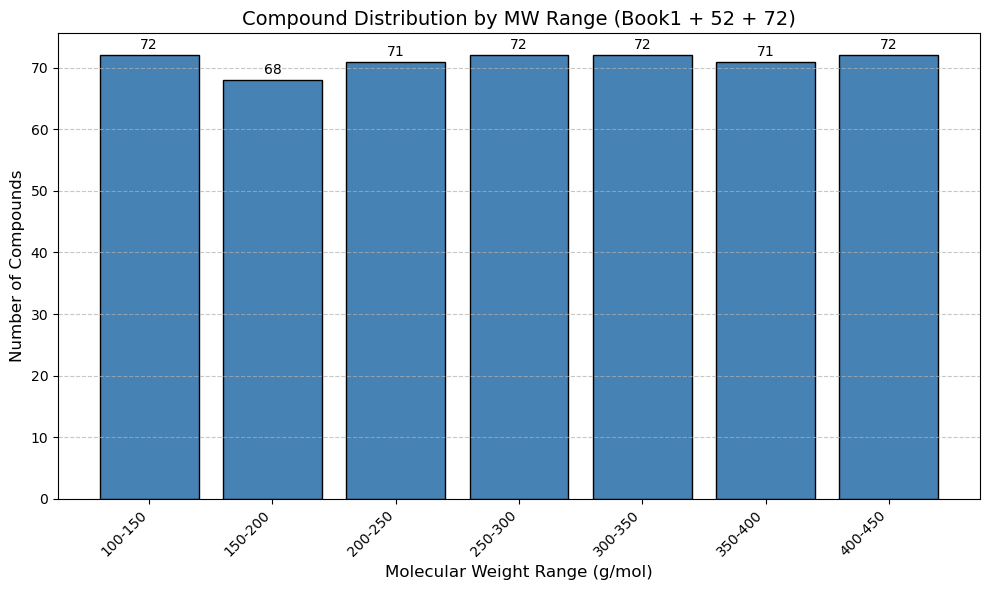


MW range counts in final dataset:
MW_range
100-150    72
150-200    68
200-250    71
250-300    72
300-350    72
350-400    71
400-450    72
Name: count, dtype: int64


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ========== CONFIGURATION ==========
BOOK1_FILE = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
FILE_52 = r"C:\Users\pljh0187\Desktop\Senushi\selected_compounds_by_MW.csv"
FILE_72 = r"C:\Users\pljh0187\Desktop\Senushi\sampled_72_MW400-450.csv"
OUTPUT_MERGED = r"C:\Users\pljh0187\Desktop\Senushi\Book1_plus_52_plus_72.csv"
OUTPUT_CONFLICTS = r"C:\Users\pljh0187\Desktop\Senushi\merge_conflicts_all.xlsx"

# Define MW ranges for the bar chart (include 400-450 for the 72 compounds)
RANGE_BINS = {
    (100, 150): 0,
    (150, 200): 0,
    (200, 250): 0,
    (250, 300): 0,
    (300, 350): 0,
    (350, 400): 0,
    (400, 450): 0
}
# ====================================

def load_csv(file_path):
    """Load CSV, clean column names, strip string columns, drop rows missing Name/SMILES."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    if 'Name' in df.columns:
        df['Name'] = df['Name'].astype(str).str.strip()
    if 'SMILES' in df.columns:
        df['SMILES'] = df['SMILES'].astype(str).str.strip()
    if 'MW' in df.columns:
        df['MW'] = pd.to_numeric(df['MW'], errors='coerce')
    return df

def check_duplicates_and_conflicts(df):
    """
    Check for exact duplicates (same Name and SMILES) and logical conflicts.
    Returns a dict with DataFrames for each issue.
    """
    # Exact duplicates (both Name and SMILES identical)
    exact_dups = df[df.duplicated(subset=['Name', 'SMILES'], keep=False)].copy()
    exact_dups = exact_dups.sort_values(['Name', 'SMILES'])
    
    # Same Name, Different SMILES
    name_dup = df[df.duplicated(subset=['Name'], keep=False)].copy()
    same_name_diff_smiles = name_dup[name_dup.duplicated(subset=['Name'], keep=False)]
    same_name_diff_smiles = same_name_diff_smiles[~same_name_diff_smiles.duplicated(subset=['Name','SMILES'], keep=False)]
    
    # Same SMILES, Different Name
    smiles_dup = df[df.duplicated(subset=['SMILES'], keep=False)].copy()
    same_smiles_diff_name = smiles_dup[smiles_dup.duplicated(subset=['SMILES'], keep=False)]
    same_smiles_diff_name = same_smiles_diff_name[~same_smiles_diff_name.duplicated(subset=['Name','SMILES'], keep=False)]
    
    return {
        'exact_duplicates': exact_dups,
        'same_name_diff_smiles': same_name_diff_smiles,
        'same_smiles_diff_name': same_smiles_diff_name
    }

def plot_mw_distribution(df, output_image=None):
    """Plot bar chart of MW distribution using predefined bins."""
    # Assign MW range labels
    def label_range(mw):
        for (low, high) in RANGE_BINS.keys():
            if low <= mw <= high:
                return f"{low}-{high}"
        return "other"
    
    df['MW_range'] = df['MW'].apply(label_range)
    # Filter only bins we care about (exclude 'other')
    plot_df = df[df['MW_range'] != 'other']
    counts = plot_df['MW_range'].value_counts().sort_index()
    
    # Reorder bins to match defined order
    ordered_bins = [f"{low}-{high}" for (low, high) in RANGE_BINS.keys()]
    counts = counts.reindex(ordered_bins, fill_value=0)
    
    # Plot
    plt.figure(figsize=(10,6))
    bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    plt.xlabel('Molecular Weight Range (g/mol)', fontsize=12)
    plt.ylabel('Number of Compounds', fontsize=12)
    plt.title('Compound Distribution by MW Range (Book1 + 52 + 72)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add count labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    
    if output_image:
        plt.savefig(output_image, dpi=150)
    plt.show()
    
    print("\nMW range counts in final dataset:")
    print(counts[counts > 0])  # only show non-zero bins

def main():
    # 1. Load all three files
    print("Loading files...")
    df_book1 = load_csv(BOOK1_FILE)
    df_52 = load_csv(FILE_52)
    df_72 = load_csv(FILE_72)
    
    print(f"Book1_cleaned: {len(df_book1)} compounds")
    print(f"52 compounds (various MW): {len(df_52)} compounds")
    print(f"72 compounds (MW 400-450): {len(df_72)} compounds")
    
    # 2. Ensure all have required columns
    for df, name in zip([df_book1, df_52, df_72], ['Book1', '52', '72']):
        if 'MW' not in df.columns:
            raise KeyError(f"'{name}' file missing 'MW' column")
        if 'Name' not in df.columns:
            raise KeyError(f"'{name}' file missing 'Name' column")
        if 'SMILES' not in df.columns:
            raise KeyError(f"'{name}' file missing 'SMILES' column")
    
    # 3. Combine
    df_combined = pd.concat([df_book1, df_52, df_72], ignore_index=True)
    df_combined.to_csv(OUTPUT_MERGED, index=False)
    print(f"\nMerged file saved to: {OUTPUT_MERGED}")
    print(f"Total rows in merged file: {len(df_combined)}")
    
    # 4. Check for duplicates and conflicts
    issues = check_duplicates_and_conflicts(df_combined)
    
    has_any_issue = (
        not issues['exact_duplicates'].empty or
        not issues['same_name_diff_smiles'].empty or
        not issues['same_smiles_diff_name'].empty
    )
    
    if has_any_issue:
        print("\n Duplicates or conflicts found! Saving details to Excel...")
        with pd.ExcelWriter(OUTPUT_CONFLICTS, engine='openpyxl') as writer:
            summary = pd.DataFrame({
                'Issue': ['Exact duplicates (Name+SMILES)',
                          'Same Name, Different SMILES',
                          'Same SMILES, Different Name'],
                'Number of rows affected': [
                    len(issues['exact_duplicates']),
                    len(issues['same_name_diff_smiles']),
                    len(issues['same_smiles_diff_name'])
                ]
            })
            summary.to_excel(writer, sheet_name='Summary', index=False)
            if not issues['exact_duplicates'].empty:
                issues['exact_duplicates'].to_excel(writer, sheet_name='Exact Duplicates', index=False)
            if not issues['same_name_diff_smiles'].empty:
                issues['same_name_diff_smiles'].to_excel(writer, sheet_name='Same Name Diff SMILES', index=False)
            if not issues['same_smiles_diff_name'].empty:
                issues['same_smiles_diff_name'].to_excel(writer, sheet_name='Same SMILES Diff Name', index=False)
        print(f"Conflicts saved to: {OUTPUT_CONFLICTS}")
        print("Please review the conflicts before proceeding.")
    else:
        print("\n No duplicates or conflicts found. Dataset is clean.")
        print("Plotting MW distribution...")
        plot_mw_distribution(df_combined, output_image=r"C:\Users\pljh0187\Desktop\Senushi\mw_distribution_merged.png")

if __name__ == "__main__":
    main()

Adding few more

In [18]:
import pandas as pd
import os
import random

# ========== CONFIGURATION ==========
BASF_FILE = r"C:\Users\pljh0187\Desktop\Senushi\basf_cleaned.csv"
BOOK1_FILE = r"C:\Users\pljh0187\Desktop\Senushi\Book1_cleaned.csv"
EXISTING_52_FILE = r"C:\Users\pljh0187\Desktop\Senushi\selected_compounds_by_MW.csv"
OUTPUT_FILE = r"C:\Users\pljh0187\Desktop\Senushi\additional_6_compounds.csv"

# MW ranges and sample sizes
RANGES = {
    (150, 200): 4,
    (200, 250): 1,
    (350, 400): 1
}

RANDOM_SEED = 42   # for reproducibility
# ====================================

def load_and_clean(file_path, required_cols=['Name', 'SMILES', 'MW']):
    """Load CSV, clean column names, strip strings, drop NaNs."""
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    for col in required_cols:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in {file_path}")
    df['Name'] = df['Name'].astype(str).str.strip()
    df['SMILES'] = df['SMILES'].astype(str).str.strip()
    if 'MW' in df.columns:
        df['MW'] = pd.to_numeric(df['MW'], errors='coerce')
        df = df.dropna(subset=['MW'])
    return df

def load_exclusion_pairs(file_path):
    """
    Load a CSV and return a set of (Name, SMILES) tuples to exclude.
    Exact match on both name and SMILES (after stripping).
    """
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found. Using empty set.")
        return set()
    df = load_and_clean(file_path, required_cols=['Name', 'SMILES'])
    # Create a set of (Name, SMILES) tuples
    exclusion_set = set(zip(df['Name'], df['SMILES']))
    return exclusion_set

def sample_from_range(df, low, high, n, exclude_pairs):
    """Randomly sample n compounds with MW in [low, high] and (Name, SMILES) not in exclude_pairs."""
    mask = (df['MW'] >= low) & (df['MW'] <= high)
    candidates = df[mask].copy()
    # Create a temporary column for exclusion check
    candidates['pair'] = list(zip(candidates['Name'], candidates['SMILES']))
    candidates = candidates[~candidates['pair'].isin(exclude_pairs)]
    candidates = candidates.drop(columns=['pair'])
    available = len(candidates)
    if available == 0:
        print(f"  WARNING: No compounds available in MW {low}-{high} after exclusions.")
        return pd.DataFrame()
    if available < n:
        print(f"  WARNING: Only {available} compounds in MW {low}-{high} (need {n}). Taking all.")
        return candidates
    else:
        return candidates.sample(n=n, random_state=RANDOM_SEED)

def main():
    # 1. Check input files
    for f in [BASF_FILE, BOOK1_FILE, EXISTING_52_FILE]:
        if not os.path.exists(f):
            print(f"ERROR: Required file not found: {f}")
            return
    
    # 2. Load BASF master data
    print("Loading BASF cleaned data...")
    basf_df = load_and_clean(BASF_FILE)
    print(f"  Compounds in BASF (after cleaning): {len(basf_df)}")
    
    # 3. Build exclusion set from Book1 and existing 52 compounds
    print("Building exclusion set...")
    exclude_book1 = load_exclusion_pairs(BOOK1_FILE)
    print(f"  Book1 unique (Name, SMILES) pairs: {len(exclude_book1)}")
    exclude_52 = load_exclusion_pairs(EXISTING_52_FILE)
    print(f"  Selected_52 unique pairs: {len(exclude_52)}")
    exclude_all = exclude_book1.union(exclude_52)
    print(f"  Total pairs to exclude: {len(exclude_all)}")
    
    # 4. Sample from each range
    selected_dfs = []
    for (low, high), n in RANGES.items():
        print(f"\nSampling {n} compounds from MW {low}-{high}...")
        sampled = sample_from_range(basf_df, low, high, n, exclude_all)
        if not sampled.empty:
            selected_dfs.append(sampled)
            print(f"  Selected {len(sampled)} compounds.")
            # Add these newly selected pairs to exclusion set to avoid reuse across ranges
            new_pairs = set(zip(sampled['Name'], sampled['SMILES']))
            exclude_all.update(new_pairs)
        else:
            print(f"  No compounds selected.")
    
    if not selected_dfs:
        print("\nNo compounds were selected. Exiting.")
        return
    
    # 5. Combine and save
    final_df = pd.concat(selected_dfs, ignore_index=True)
    final_df = final_df[['Name', 'SMILES', 'MW']].copy()
    
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f"\nSuccessfully saved {len(final_df)} compounds to:")
    print(f"  {OUTPUT_FILE}")
    
    # 6. Summary
    print("\nSelection summary:")
    for (low, high), n in RANGES.items():
        count = len(final_df[(final_df['MW'] >= low) & (final_df['MW'] <= high)])
        print(f"  MW {low}-{high}: {count} compounds selected")

if __name__ == "__main__":
    main()

Loading BASF cleaned data...
  Compounds in BASF (after cleaning): 3917
Building exclusion set...
  Book1 unique (Name, SMILES) pairs: 375
  Selected_52 unique pairs: 51
  Total pairs to exclude: 426

Sampling 4 compounds from MW 150-200...
  Selected 4 compounds.

Sampling 1 compounds from MW 200-250...
  Selected 1 compounds.

Sampling 1 compounds from MW 350-400...
  Selected 1 compounds.

Successfully saved 6 compounds to:
  C:\Users\pljh0187\Desktop\Senushi\additional_6_compounds.csv

Selection summary:
  MW 150-200: 4 compounds selected
  MW 200-250: 1 compounds selected
  MW 350-400: 1 compounds selected


Merging the files

In [25]:
import pandas as pd
import os

# ========== CONFIGURATION ==========
EXISTING_MERGED = r"C:\Users\pljh0187\Desktop\Senushi\Book1_plus_52_plus_72.csv"
NEW_6_FILE = r"C:\Users\pljh0187\Desktop\Senushi\additional_6_compounds.csv"
OUTPUT_MERGED = r"C:\Users\pljh0187\Desktop\Senushi\Book1_plus_52_plus_72_plus_6.csv"
OUTPUT_CONFLICTS = r"C:\Users\pljh0187\Desktop\Senushi\merge_conflicts_final.xlsx"
# ====================================

def load_csv(file_path, required_cols=None):
    """Load CSV, clean column names, strip string columns, convert MW to numeric."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    if 'Name' in df.columns:
        df['Name'] = df['Name'].astype(str).str.strip()
    if 'SMILES' in df.columns:
        df['SMILES'] = df['SMILES'].astype(str).str.strip()
    if 'MW' in df.columns:
        df['MW'] = pd.to_numeric(df['MW'], errors='coerce')
    if required_cols:
        for col in required_cols:
            if col not in df.columns:
                raise KeyError(f"Column '{col}' not found in {file_path}")
    return df

def check_duplicates_and_conflicts(df):
    """Check for exact duplicates and logical conflicts."""
    # Exact duplicates (Name + SMILES)
    exact_dups = df[df.duplicated(subset=['Name', 'SMILES'], keep=False)].copy()
    exact_dups = exact_dups.sort_values(['Name', 'SMILES'])
    
    # Same Name, Different SMILES
    name_dup = df[df.duplicated(subset=['Name'], keep=False)].copy()
    same_name_diff_smiles = name_dup[~name_dup.duplicated(subset=['Name','SMILES'], keep=False)]
    
    # Same SMILES, Different Name
    smiles_dup = df[df.duplicated(subset=['SMILES'], keep=False)].copy()
    same_smiles_diff_name = smiles_dup[~smiles_dup.duplicated(subset=['Name','SMILES'], keep=False)]
    
    return {
        'exact_duplicates': exact_dups,
        'same_name_diff_smiles': same_name_diff_smiles,
        'same_smiles_diff_name': same_smiles_diff_name
    }

def main():
    # 1. Load existing merged file and new 6 compounds
    print("Loading existing merged dataset...")
    df_existing = load_csv(EXISTING_MERGED, required_cols=['Name', 'SMILES', 'MW'])
    print(f"Existing rows: {len(df_existing)}")
    
    print("Loading new 6 compounds...")
    df_new = load_csv(NEW_6_FILE, required_cols=['Name', 'SMILES', 'MW'])
    print(f"New compounds: {len(df_new)}")
    
    # 2. Combine and save merged file (always)
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(OUTPUT_MERGED, index=False)
    print(f"\nMerged file saved to: {OUTPUT_MERGED}")
    print(f"Total rows in merged file: {len(df_combined)}")
    
    # 3. Check for duplicates and conflicts
    issues = check_duplicates_and_conflicts(df_combined)
    has_any_issue = (
        not issues['exact_duplicates'].empty or
        not issues['same_name_diff_smiles'].empty or
        not issues['same_smiles_diff_name'].empty
    )
    
    if has_any_issue:
        print("\n Duplicates or conflicts found! Saving details to Excel...")
        with pd.ExcelWriter(OUTPUT_CONFLICTS, engine='openpyxl') as writer:
            summary = pd.DataFrame({
                'Issue': ['Exact duplicates (Name+SMILES)',
                          'Same Name, Different SMILES',
                          'Same SMILES, Different Name'],
                'Number of rows affected': [
                    len(issues['exact_duplicates']),
                    len(issues['same_name_diff_smiles']),
                    len(issues['same_smiles_diff_name'])
                ]
            })
            summary.to_excel(writer, sheet_name='Summary', index=False)
            if not issues['exact_duplicates'].empty:
                issues['exact_duplicates'].to_excel(writer, sheet_name='Exact Duplicates', index=False)
            if not issues['same_name_diff_smiles'].empty:
                issues['same_name_diff_smiles'].to_excel(writer, sheet_name='Same Name Diff SMILES', index=False)
            if not issues['same_smiles_diff_name'].empty:
                issues['same_smiles_diff_name'].to_excel(writer, sheet_name='Same SMILES Diff Name', index=False)
        print(f"Conflicts saved to: {OUTPUT_CONFLICTS}")
    else:
        print("\n No duplicates or conflicts found. Dataset is clean (no conflict file created).")

if __name__ == "__main__":
    main()

Loading existing merged dataset...
Existing rows: 498
Loading new 6 compounds...
New compounds: 6

Merged file saved to: C:\Users\pljh0187\Desktop\Senushi\Book1_plus_52_plus_72_plus_6.csv
Total rows in merged file: 504

 Duplicates or conflicts found! Saving details to Excel...
Conflicts saved to: C:\Users\pljh0187\Desktop\Senushi\merge_conflicts_final.xlsx


Creating the Bar Chart

Loading C:\Users\pljh0187\Desktop\Senushi\Book2.csv...
Total compounds (with valid MW): 502


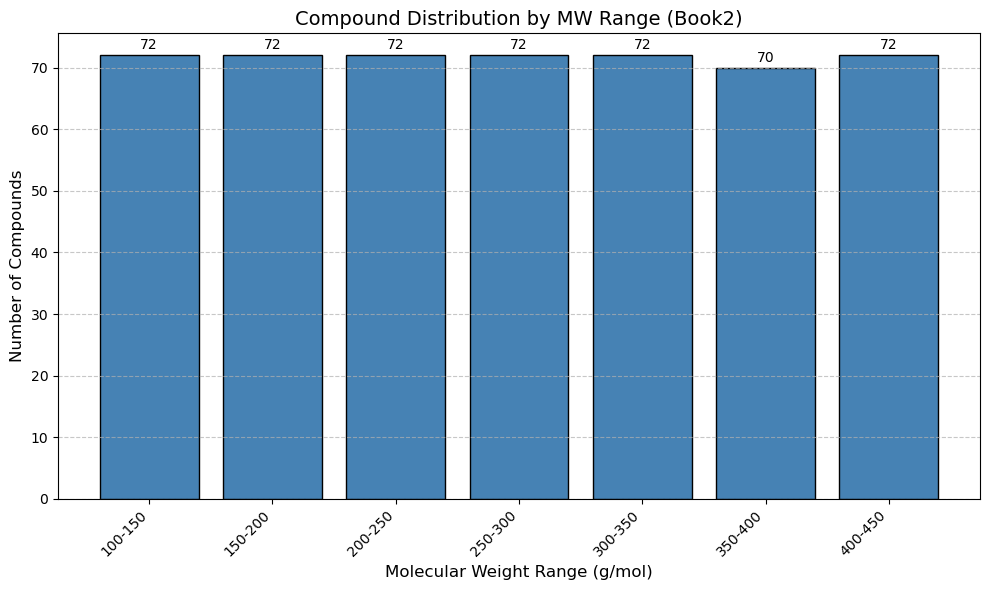


MW range counts in Book2:
MW_range
100-150    72
150-200    72
200-250    72
250-300    72
300-350    72
350-400    70
400-450    72
Name: count, dtype: int64


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ========== CONFIGURATION ==========
FILE_PATH = r"C:\Users\pljh0187\Desktop\Senushi\Book2.csv"

# Define MW ranges (same as used previously)
MW_BINS = {
    (100, 150): 0,
    (150, 200): 0,
    (200, 250): 0,
    (250, 300): 0,
    (300, 350): 0,
    (350, 400): 0,
    (400, 450): 0
}
# ====================================

def load_and_clean(file_path):
    """Load CSV, clean, convert MW to numeric."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    if 'MW' not in df.columns:
        raise KeyError(f"Column 'MW' not found in {file_path}")
    df['MW'] = pd.to_numeric(df['MW'], errors='coerce')
    df = df.dropna(subset=['MW'])
    return df

def plot_mw_distribution(df, output_image=None):
    """Plot bar chart of MW distribution using predefined bins."""
    def label_range(mw):
        for (low, high) in MW_BINS.keys():
            if low <= mw <= high:
                return f"{low}-{high}"
        return "other"
    
    df['MW_range'] = df['MW'].apply(label_range)
    plot_df = df[df['MW_range'] != 'other']
    counts = plot_df['MW_range'].value_counts().sort_index()
    
    # Reorder to match bin order
    ordered_bins = [f"{low}-{high}" for (low, high) in MW_BINS.keys()]
    counts = counts.reindex(ordered_bins, fill_value=0)
    
    plt.figure(figsize=(10,6))
    bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    plt.xlabel('Molecular Weight Range (g/mol)', fontsize=12)
    plt.ylabel('Number of Compounds', fontsize=12)
    plt.title('Compound Distribution by MW Range (Book2)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    
    if output_image:
        plt.savefig(output_image, dpi=150)
    plt.show()
    
    print("\nMW range counts in Book2:")
    print(counts[counts > 0])

def main():
    print(f"Loading {FILE_PATH}...")
    df = load_and_clean(FILE_PATH)
    print(f"Total compounds (with valid MW): {len(df)}")
    plot_mw_distribution(df, output_image=r"C:\Users\pljh0187\Desktop\Senushi\book2_mw_distribution.png")

if __name__ == "__main__":
    main()